# IF25-40305: Sistem Teknologi Multimedia (STM)
## Modul 02 — Audio Visual Representation: Waveform, Spectrum, Spectrogram & Mel-Scale

**Institut Teknologi Sumatera (ITERA) — Program Studi Informatika**
*Materi Kuliah & Hands-on Lab Semester Ganjil 2026/2027*

---

### 🎯 Capaian Pembelajaran (Learning Outcomes)
Setelah menyelesaikan modul hands-on ini, mahasiswa diharapkan mampu:
1. **Memahami Tiga Dimensi Fundamental Sinyal Audio**: Menjelaskan hubungan antara waktu ($t$), frekuensi ($f$), dan amplitudo ($A$), serta memahami mengapa tidak ada satu tampilan visual pun yang mampu menyajikan ketiganya secara sempurna sekaligus.
2. **Membaca Waveform (Domain Waktu)**: Mengidentifikasi daerah hening, transien ketukan, nada sustain, dan distorsi *clipping* pada tampilan amplitudo terhadap waktu, sekaligus memahami keterbatasan "buta frekuensi" dari tampilan ini.
3. **Menghitung Spektrum FFT Berskala dBFS yang Benar**: Menerapkan *windowing* Hann beserta koreksi normalisasi window, sehingga nilai dBFS yang tampil benar-benar terkalibrasi dan bukan sekadar angka relatif tanpa makna.
4. **Melakukan Forensik Frekuensi**: Menemukan duri dengung jala listrik ($50\text{ Hz}$) dan memetakan energi audio ke dalam lima zona spektrum (*Sub-Bass*, *Bass*, *Midrange*, *Presence*, *Treble/Air*) sebagai dasar pengambilan keputusan *Equalizer*.
5. **Menafsirkan Spektrogram (STFT)**: Membaca garis vertikal (transien), garis horizontal (dengung/sustain), dan garis bertingkat (deret harmonik), serta menganalisis *trade-off* antara resolusi waktu dan resolusi frekuensi melalui parameter `n_fft`.
6. **Menerapkan Skala Perseptual Mel**: Menjelaskan formula skala Mel, membuktikan secara kuantitatif bahwa skala Mel memperbesar porsi daerah vokal, dan memahami alasan skala ini menjadi standar emas model AI audio seperti OpenAI Whisper.
7. **Membaca Tampilan Equalizer Modern (RTA)**: Menafsirkan antarmuka *Equalizer* studio yang menggabungkan spektrum RTA *real-time* dengan kurva respons filter beserta titik-titik kontrolnya (*nodes*).

## 1. Import Library & Persiapan Lingkungan

Modul ini bertumpu pada ekosistem saintifik Python yang sama dengan Modul 01, dengan penambahan
komponen khusus analisis waktu-frekuensi:
- `numpy`: Manipulasi array sinyal, transformasi Fourier (`np.fft.rfft`), dan operasi matematis.
- `matplotlib.pyplot`: Seluruh visualisasi — waveform, spektrum, spektrogram, dan mockup antarmuka EQ.
- `scipy.signal`: Pembangkitan *window* Hann (`get_window`) untuk analisis spektrum yang terkalibrasi.
- `librosa` + `librosa.display`: Perhitungan STFT, Mel-spektrogram, *filterbank* Mel, dan penggambaran spektrogram (`specshow`).
- `soundfile`: Pembacaan berkas audio WAV.
- `IPython.display`: Pemutar audio interaktif di dalam notebook.

> ⚠️ **Catatan versi.** Notebook ini disusun untuk **librosa 1.0**. Pada versi tersebut hampir
> seluruh argumen bersifat *keyword-only*, sehingga penulisan `librosa.stft(y, 2048)` akan gagal
> dan harus ditulis `librosa.stft(y, n_fft=2048)`. Sel di bawah akan mencetak versi pustaka yang
> benar-benar terpasang pada komputer Anda.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd
from IPython.display import display

# Konfigurasi visualisasi agar tajam, rapi, dan konsisten dengan Modul 01
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# Palet warna konsisten: dipakai ulang di seluruh notebook agar tiap konsep
# selalu diwakili warna yang sama pada setiap gambar.
C_SIGNAL   = '#0284c7'   # biru   — sinyal utama / bersih
C_ALT      = '#0ea5e9'   # langit — sinyal pembanding
C_NEUTRAL  = '#334155'   # slate  — audio mentah, teks netral
C_ALERT    = '#dc2626'   # merah  — cacat, batas bahaya, dengung
C_GOOD     = '#059669'   # hijau  — kondisi benar / target
C_ACCENT   = '#7c3aed'   # violet — sorotan tersier
C_GOLD     = '#c5a059'   # emas   — panel Mel

# Pemutar audio dibatasi beberapa detik pertama saja. Durasi ini sudah lebih dari
# cukup untuk mendengar perbedaan, sekaligus menjaga ukuran berkas notebook tetap
# ringan ketika disimpan lengkap dengan seluruh keluarannya.
PREVIEW_S = 5.0


def putar(sig, sr, label):
    """Menampilkan pemutar audio untuk beberapa detik pertama sinyal."""
    print(label)
    display(ipd.Audio(sig[:int(PREVIEW_S * sr)], rate=sr))


print(f"numpy      : {np.__version__}")
print(f"librosa    : {librosa.__version__}")
print(f"soundfile  : {sf.__version__}")
print("\n✅ Seluruh pustaka analisis audio berhasil dimuat!")

numpy      : 2.5.3
librosa    : 1.0.0
soundfile  : 0.14.0

✅ Seluruh pustaka analisis audio berhasil dimuat!


## 2. Memuat Audio & Menyuntikkan Cacat Realistis

### 🎼 Berkas Audio yang Digunakan
Sepanjang modul ini kita memakai **satu berkas audio yang sama** agar perbandingan antar tampilan
menjadi adil — persis seperti empat foto Rontgen atas satu pasien yang sama.

Berkas `music_sample.wav` adalah potongan 10 detik dari lagu **"Vibe Ace" karya Kevin MacLeod**
(lisensi [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)). Berkas ini dipilih karena
dalam satu rekaman sekaligus memuat tiga bahan ajar yang kita butuhkan:

| Elemen musik | Yang akan terlihat pada visualisasi |
|---|---|
| **Drum kit** | Paku vertikal transien pada waveform & spektrogram |
| **Vibraphone & piano** | Deret harmonik bertingkat pada spektrogram |
| **Bass** | Energi kuat di zona frekuensi rendah pada spektrum FFT |

### 🧪 Mengapa Perlu Menyuntikkan Cacat?
Rekaman studio profesional sudah bersih — padahal justru **cacat audio** yang paling perlu kita
latih untuk dikenali secara visual. Karena itu kita akan menambahkan dua gangguan yang paling
sering ditemui teknisi audio di lapangan:

1. **Dengung jala listrik $50\text{ Hz}$** (*mains hum*) beserta harmonik $100\text{ Hz}$ dan
   $150\text{ Hz}$ — muncul akibat induksi kabel listrik atau *ground loop*. Di Indonesia frekuensi
   jala listrik adalah $50\text{ Hz}$; di Amerika Serikat $60\text{ Hz}$.
2. **Gemuruh frekuensi sangat rendah** (*rumble*, $< 40\text{ Hz}$) — muncul akibat getaran meja,
   hentakan kaki, atau embusan angin ke mikrofon.

Kedua cacat ini nyaris **tidak terlihat pada waveform**, namun akan sangat mencolok begitu kita
berpindah ke domain frekuensi. Perbedaan inilah pelajaran utama modul ini.

In [2]:
# Pencarian berkas defensif: notebook tetap berjalan baik dari root repositori
# maupun dari dalam folder notebook_handson/, dan tetap hidup di Google Colab.
possible_paths = [
    'audio/music_sample.wav',
    'notebook_handson/audio/music_sample.wav',
    '../audio/music_sample.wav',
]
audio_path = next((p for p in possible_paths if os.path.exists(p)), None)

if audio_path is None:
    print("Berkas lokal tidak ditemukan. Mengunduh 'Vibe Ace' dari pustaka contoh librosa...")
    audio_path = librosa.ex('vibeace')

SR = 22050
y_clean, sr = librosa.load(audio_path, sr=SR, mono=True, duration=10.0)
t = np.arange(len(y_clean)) / sr

print(f"Sumber berkas     : {audio_path}")
print(f"Laju sampel       : {sr} Hz")
print(f"Jumlah sampel     : {len(y_clean)} sampel")
print(f"Durasi            : {len(y_clean)/sr:.2f} detik")
print(f"Puncak amplitudo  : {np.max(np.abs(y_clean)):.3f} ({20*np.log10(np.max(np.abs(y_clean))):.2f} dBFS)")

putar(y_clean, sr, "\n🎵 Audio asli (bersih), sebelum disuntik cacat apa pun:")

Sumber berkas     : audio/music_sample.wav
Laju sampel       : 22050 Hz
Jumlah sampel     : 220500 sampel
Durasi            : 10.00 detik
Puncak amplitudo  : 0.708 (-3.00 dBFS)

🎵 Audio asli (bersih), sebelum disuntik cacat apa pun:


In [3]:
def inject_defects(y, sr, hum_freq=50.0, hum_amp=0.05, rumble_amp=0.06, seed=40305):
    """Menyuntikkan dengung jala listrik dan gemuruh frekuensi rendah ke sinyal bersih.

    Dengung dimodelkan sebagai nada dasar ditambah harmonik ke-2 dan ke-3 yang melemah,
    persis seperti karakter dengung listrik sungguhan. Gemuruh dimodelkan sebagai derau
    acak yang hanya menyisakan komponen sangat rendah.
    """
    rng = np.random.default_rng(seed)
    tt = np.arange(len(y)) / sr

    # Dengung 50 Hz + harmonik 100 Hz (1/2 kuat) + 150 Hz (1/3 kuat)
    hum = np.zeros_like(y)
    for k in (1, 2, 3):
        hum += (hum_amp / k) * np.sin(2 * np.pi * hum_freq * k * tt)

    # Gemuruh: derau acak yang "diperhalus" berulang kali sehingga hanya
    # menyisakan gerak yang sangat lambat, yaitu komponen frekuensi sangat rendah.
    noise = rng.standard_normal(len(y))
    kernel = np.ones(int(sr / 40)) / int(sr / 40)          # rata-rata bergerak ~40 Hz
    for _ in range(3):
        noise = np.convolve(noise, kernel, mode='same')
    rumble = rumble_amp * noise / np.max(np.abs(noise))

    return y + hum + rumble


y_dirty = inject_defects(y_clean, sr)

print(f"Puncak sebelum disuntik : {20*np.log10(np.max(np.abs(y_clean))):6.2f} dBFS")
print(f"Puncak sesudah disuntik : {20*np.log10(np.max(np.abs(y_dirty))):6.2f} dBFS")
print("\nSilakan bandingkan dengan telinga — dengung terdengar sebagai desis rendah")
print("yang menggantung konstan di latar belakang:\n")

putar(y_clean, sr, "🎵 1. Audio BERSIH:")
putar(y_dirty, sr, "🎵 2. Audio TERCEMAR (dengung 50 Hz + gemuruh):")

Puncak sebelum disuntik :  -3.00 dBFS
Puncak sesudah disuntik :  -2.90 dBFS

Silakan bandingkan dengan telinga — dengung terdengar sebagai desis rendah
yang menggantung konstan di latar belakang:

🎵 1. Audio BERSIH:


🎵 2. Audio TERCEMAR (dengung 50 Hz + gemuruh):


## 3. Domain Waktu: Waveform

### 📈 Cara Membaca Waveform
Waveform adalah tampilan paling dasar sekaligus paling intuitif: **sumbu X adalah waktu ($t$)**
dan **sumbu Y adalah amplitudo ($A$)**, umumnya dinormalisasi pada rentang $-1{,}0$ hingga $+1{,}0$.

| Pola visual | Artinya |
|---|---|
| Puncak tinggi | Suara keras (*loud*) |
| Garis datar mendekati nol | Daerah hening (*silence*) |
| Paku vertikal mendadak | Transien ketukan perkusi |
| Puncak rata terpotong di $\pm 1{,}0$ | **Clipping** — distorsi digital! |

### ⚠️ Batasan Kritis: Waveform "Buta Frekuensi"
Inilah keterbatasan paling penting yang harus dipahami: waveform **tidak dapat memberi tahu nada
apa yang sedang berbunyi**. Sebuah dentuman bass $60\text{ Hz}$ dan sebuah vokal melengking
$3\text{ kHz}$ dengan kekerasan sama akan tampil sebagai waveform setinggi persis sama.

Konsekuensi praktisnya: dengung $50\text{ Hz}$ yang baru saja kita suntikkan pada dasarnya
**tidak akan terlihat** pada tampilan ini. Buktikan sendiri pada gambar berikut.

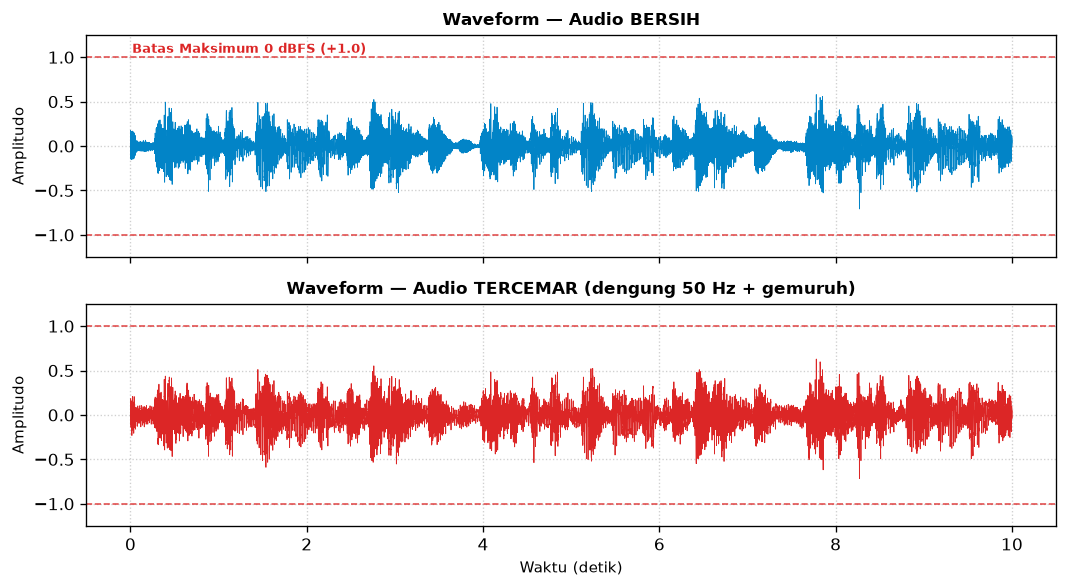

Selisih amplitudo maksimum akibat cacat : 0.132
Perubahan puncak keseluruhan            : 0.10 dB

👉 Mata hampir tidak dapat membedakan kedua waveform di atas, padahal telinga
   jelas mendengar dengungnya. Inilah alasan kita membutuhkan domain frekuensi.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, sharey=True)

for ax, sig, judul, warna in (
    (axes[0], y_clean, 'Audio BERSIH', C_SIGNAL),
    (axes[1], y_dirty, 'Audio TERCEMAR (dengung 50 Hz + gemuruh)', C_ALERT),
):
    ax.plot(t, sig, color=warna, lw=0.5)
    ax.set_title(f"Waveform — {judul}", fontsize=10, fontweight='bold')
    ax.set_ylabel("Amplitudo", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    # Garis batas 0 dBFS: melewati garis ini berarti clipping
    for batas in (1.0, -1.0):
        ax.axhline(batas, color=C_ALERT, lw=1.0, linestyle='--', alpha=0.8)
    ax.set_ylim(-1.25, 1.25)

axes[0].text(0.02, 1.05, "Batas Maksimum 0 dBFS (+1.0)", color=C_ALERT,
             fontsize=8, fontweight='bold')
axes[1].set_xlabel("Waktu (detik)", fontsize=9)
plt.tight_layout()
plt.show()

# Bukti kuantitatif bahwa waveform hampir tidak berubah oleh cacat yang disuntikkan
selisih = np.max(np.abs(y_dirty - y_clean))
print(f"Selisih amplitudo maksimum akibat cacat : {selisih:.3f}")
print(f"Perubahan puncak keseluruhan            : "
      f"{20*np.log10(np.max(np.abs(y_dirty))) - 20*np.log10(np.max(np.abs(y_clean))):.2f} dB")
print("\n👉 Mata hampir tidak dapat membedakan kedua waveform di atas, padahal telinga")
print("   jelas mendengar dengungnya. Inilah alasan kita membutuhkan domain frekuensi.")

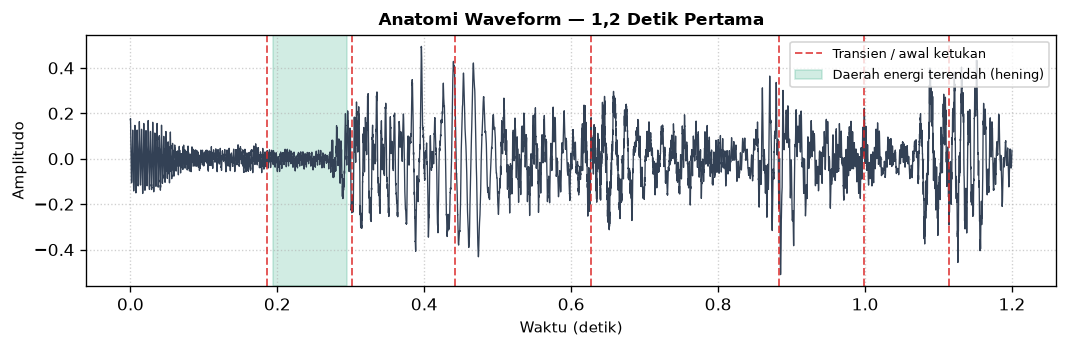

Terdeteksi 7 transien dalam 1.2 detik pertama.
Waktu transien (detik): [0.186 0.302 0.441 0.627 0.882 0.998 1.115]


In [5]:
# Membedah 1,2 detik pertama untuk melihat struktur mikro waveform:
# daerah hening, transien ketukan, dan nada sustain.
zoom_dur = 1.2
n_zoom = int(zoom_dur * sr)
env = np.abs(y_clean[:n_zoom])

onset_times = librosa.onset.onset_detect(y=y_clean, sr=sr, units='time')
onset_zoom = onset_times[onset_times < zoom_dur]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t[:n_zoom], y_clean[:n_zoom], color=C_NEUTRAL, lw=0.8)

for i, ot in enumerate(onset_zoom):
    ax.axvline(ot, color=C_ALERT, lw=1.2, linestyle='--', alpha=0.75,
               label='Transien / awal ketukan' if i == 0 else None)

# Daerah dengan energi terendah pada potongan ini = bagian paling "hening"
win = int(0.05 * sr)
energi = np.convolve(env, np.ones(win) / win, mode='same')
i_quiet = int(np.argmin(energi[win:n_zoom - win])) + win
ax.axvspan((i_quiet - win) / sr, (i_quiet + win) / sr, color=C_GOOD, alpha=0.18,
           label='Daerah energi terendah (hening)')

ax.set_title("Anatomi Waveform — 1,2 Detik Pertama", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Amplitudo", fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Terdeteksi {len(onset_zoom)} transien dalam {zoom_dur} detik pertama.")
print(f"Waktu transien (detik): {np.round(onset_zoom, 3)}")

### 🔊 Demonstrasi Clipping: Ketika Sinyal Menabrak Langit-langit

*Clipping* terjadi saat amplitudo sinyal melampaui batas maksimum yang dapat direpresentasikan
sistem digital ($\pm 1{,}0$). Puncak gelombang terpotong rata, dan telinga mendengarnya sebagai
**distorsi kasar yang pecah**.

Di bawah ini kita memperkuat sinyal sebesar $+12\text{ dB}$ secara sengaja, lalu memotong paksa
nilai yang melewati batas. Perhatikan bagaimana puncak yang semula melengkung berubah menjadi
dataran datar — dan dengarkan perbedaannya.

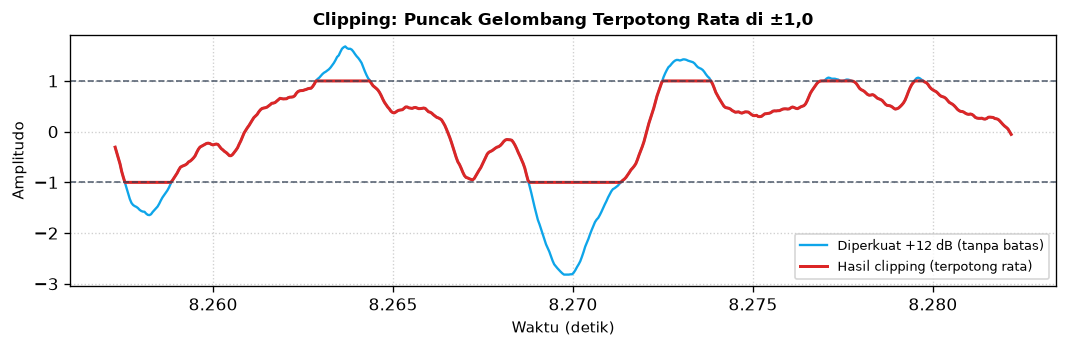

Sampel yang mengalami clipping : 15093 dari 220500 (6.84%)

🎵 1. Audio normal:


🎵 2. Audio ter-clipping (dengarkan distorsi kasarnya):


In [6]:
gain_db = 12.0
y_loud = y_clean * 10 ** (gain_db / 20)
y_clip = np.clip(y_loud, -1.0, 1.0)

n_clipped = int(np.sum(np.abs(y_loud) > 1.0))
persen = 100 * n_clipped / len(y_loud)

# Ambil jendela 25 ms di sekitar puncak tertinggi agar bentuk pemotongan terlihat jelas
i_peak = int(np.argmax(np.abs(y_loud)))
half = int(0.0125 * sr)
sl = slice(max(0, i_peak - half), min(len(y_loud), i_peak + half))

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t[sl], y_loud[sl], color=C_ALT, lw=1.4, label=f'Diperkuat +{gain_db:.0f} dB (tanpa batas)')
ax.plot(t[sl], y_clip[sl], color=C_ALERT, lw=1.8, label='Hasil clipping (terpotong rata)')
for batas in (1.0, -1.0):
    ax.axhline(batas, color=C_NEUTRAL, lw=1.0, linestyle='--', alpha=0.8)

ax.set_title("Clipping: Puncak Gelombang Terpotong Rata di ±1,0", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Amplitudo", fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Sampel yang mengalami clipping : {n_clipped} dari {len(y_loud)} ({persen:.2f}%)")
putar(y_clean, sr, "\n🎵 1. Audio normal:")
putar(y_clip, sr, "🎵 2. Audio ter-clipping (dengarkan distorsi kasarnya):")

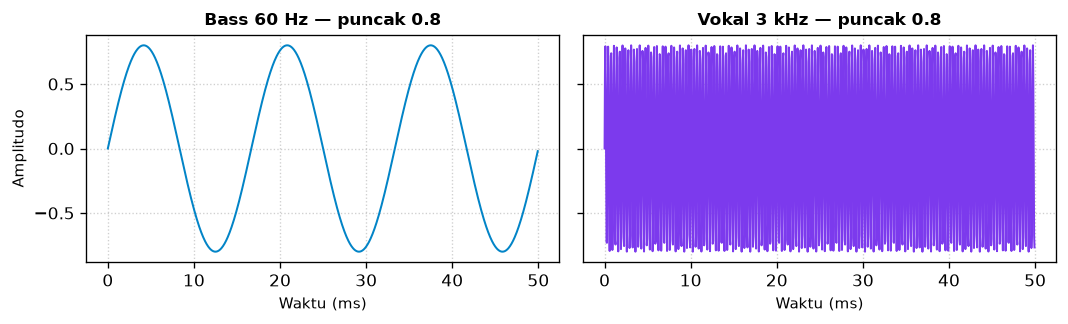

Puncak bass 60 Hz   : 0.800
Puncak vokal 3 kHz  : 0.800

👉 Nilai puncaknya identik. Sebuah pengukur berbasis amplitudo tidak akan mampu
   membedakan keduanya — meskipun telinga mendengarnya sebagai dua suara
   yang sama sekali berbeda. Untuk itulah domain frekuensi diperlukan.


In [7]:
# Bukti "buta frekuensi": dua nada dengan frekuensi sangat berbeda,
# namun amplitudo identik, menghasilkan waveform setinggi persis sama.
dur = 0.05
tt = np.arange(int(dur * sr)) / sr
bass  = 0.8 * np.sin(2 * np.pi * 60 * tt)     # dentuman bass 60 Hz
vokal = 0.8 * np.sin(2 * np.pi * 3000 * tt)   # vokal melengking 3 kHz

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharey=True)
for ax, sig, judul, warna in (
    (axes[0], bass,  'Bass 60 Hz',   C_SIGNAL),
    (axes[1], vokal, 'Vokal 3 kHz',  C_ACCENT),
):
    ax.plot(tt * 1000, sig, color=warna, lw=1.2)
    ax.set_title(f"{judul} — puncak {np.max(np.abs(sig)):.1f}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Waktu (ms)", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
axes[0].set_ylabel("Amplitudo", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Puncak bass 60 Hz   : {np.max(np.abs(bass)):.3f}")
print(f"Puncak vokal 3 kHz  : {np.max(np.abs(vokal)):.3f}")
print("\n👉 Nilai puncaknya identik. Sebuah pengukur berbasis amplitudo tidak akan mampu")
print("   membedakan keduanya — meskipun telinga mendengarnya sebagai dua suara")
print("   yang sama sekali berbeda. Untuk itulah domain frekuensi diperlukan.")

## 4. Domain Frekuensi: Spektrum FFT

### 🔍 Prisma Pengurai Frekuensi
*Fast Fourier Transform* (FFT) bekerja seperti prisma: ia membedah sinyal campuran menjadi
spektrum frekuensi murni penyusunnya. **Sumbu X adalah frekuensi** (digambar pada skala
logaritmik agar sebaran $20\text{ Hz}$–$20\text{ kHz}$ proporsional dengan pendengaran manusia),
dan **sumbu Y adalah tingkat daya** dalam dBFS.

### 📐 Menghitung dBFS yang Benar-Benar Terkalibrasi
Banyak tutorial menuliskan spektrum sebagai `20*log10(abs(rfft(x)))` begitu saja. Cara itu
menghasilkan bentuk kurva yang benar, tetapi **angka dBFS-nya tidak bermakna** — nilainya ikut
berubah hanya karena panjang potongan sinyal diubah.

Agar sumbu Y benar-benar dapat dibaca sebagai dBFS, diperlukan dua koreksi:

1. **Normalisasi terhadap jumlah koefisien window** ($\sum w$), bukan terhadap panjang sinyal $N$.
   Window Hann meredam tepi potongan, sehingga energi total ikut berkurang dan harus dikompensasi.
   Melewatkan koreksi ini membuat seluruh pembacaan meleset sekitar $6\text{ dB}$.
2. **Pengali $2$** karena `rfft` hanya mengembalikan spektrum satu sisi, sedangkan energi sinyal
   nyata terbagi rata ke frekuensi positif dan negatif. Pengali ini **tidak berlaku** untuk bin DC
   dan bin Nyquist, karena keduanya tidak memiliki pasangan cermin.

$$\text{dBFS}(f) = 20 \log_{10}\left( \frac{2 \cdot |\text{rfft}(x \cdot w)|}{\sum w} \right)$$

Selain itu, satu potongan FFT atas rekaman musik sepanjang 10 detik menghasilkan kurva yang
sangat bergerigi, karena musik terus berubah. Karena itu kita **merata-ratakan magnitudo lintas
beberapa jendela yang saling bertumpang tindih**. Komponen yang datang dan pergi akan saling
meredam, sedangkan komponen yang menetap — seperti dengung listrik — justru makin menonjol.

> 🔁 **Peningkatan dari Modul 01.** Di Modul 01 spektrum dihitung tanpa *window* dan digambar pada
> skala magnitudo linier. Di sini kita memperbaikinya dengan tiga hal sekaligus: koreksi *window*,
> skala dBFS terkalibrasi, dan sumbu frekuensi logaritmik.

**Uji kebenaran:** nada sinus beramplitudo $1{,}0$ harus berpuncak tepat di $0\text{ dBFS}$, dan
amplitudo $0{,}5$ tepat di $-6{,}02\text{ dBFS}$. Kita verifikasi dahulu sebelum mempercayai
gambar apa pun.

In [8]:
def spectrum_dbfs(x, sr, n_fft=4096, average=True):
    """Menghitung spektrum satu sisi berskala dBFS yang terkalibrasi.

    Bila `average=True` dan sinyal lebih panjang dari satu jendela, magnitudo
    dirata-ratakan lintas jendela yang saling bertumpang tindih 50%.

    Mengembalikan (frekuensi_hz, magnitudo_dbfs).
    """
    x = np.asarray(x, dtype=float)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))

    w = get_window('hann', n_fft, fftbins=True)          # window periodik, bukan np.hanning
    hop = n_fft // 2
    n_frames = 1 + (len(x) - n_fft) // hop if average else 1

    akumulasi = np.zeros(n_fft // 2 + 1)
    for i in range(n_frames):
        seg = x[i * hop: i * hop + n_fft]
        akumulasi += np.abs(np.fft.rfft(seg * w))
    mag = akumulasi / n_frames / np.sum(w)

    # Koreksi spektrum satu sisi: tidak dikenakan pada bin DC dan bin Nyquist,
    # karena kedua bin tersebut tidak memiliki pasangan frekuensi negatif.
    mag[1:-1] *= 2.0

    db = 20 * np.log10(np.maximum(mag, 1e-12))
    freqs = np.fft.rfftfreq(n_fft, 1 / sr)
    return freqs, db


# --- Uji kalibrasi: nada tepat di tengah bin agar bebas dari scalloping loss ---
N_uji = 4096
f_bins = np.fft.rfftfreq(N_uji, 1 / SR)
f_uji = f_bins[186]                                       # ≈ 1001,29 Hz, tepat di tengah bin
t_uji = np.arange(N_uji) / SR

print("Verifikasi kalibrasi dBFS (nada uji tepat di tengah bin):")
print(f"  Frekuensi nada uji : {f_uji:.2f} Hz\n")
for amp in (1.0, 0.5, 0.1):
    _, db_uji = spectrum_dbfs(amp * np.sin(2 * np.pi * f_uji * t_uji), SR, n_fft=N_uji)
    target = 20 * np.log10(amp)
    print(f"  amplitudo {amp:<4} -> puncak {db_uji.max():8.4f} dBFS   (target {target:7.2f} dBFS)")

print("\n✅ Selisihnya nol. Sumbu dBFS pada seluruh grafik berikutnya kini sahih.")
print("\nℹ️  Catatan: nada yang TIDAK tepat jatuh di tengah bin akan terbaca sekitar")
print("   0,3 dB lebih rendah. Gejala ini bernama *scalloping loss* dan merupakan")
print("   sifat wajar analisis FFT — bukan kesalahan program.")

Verifikasi kalibrasi dBFS (nada uji tepat di tengah bin):
  Frekuensi nada uji : 1001.29 Hz

  amplitudo 1.0  -> puncak  -0.0000 dBFS   (target    0.00 dBFS)
  amplitudo 0.5  -> puncak  -6.0206 dBFS   (target   -6.02 dBFS)
  amplitudo 0.1  -> puncak -20.0000 dBFS   (target  -20.00 dBFS)

✅ Selisihnya nol. Sumbu dBFS pada seluruh grafik berikutnya kini sahih.

ℹ️  Catatan: nada yang TIDAK tepat jatuh di tengah bin akan terbaca sekitar
   0,3 dB lebih rendah. Gejala ini bernama *scalloping loss* dan merupakan
   sifat wajar analisis FFT — bukan kesalahan program.


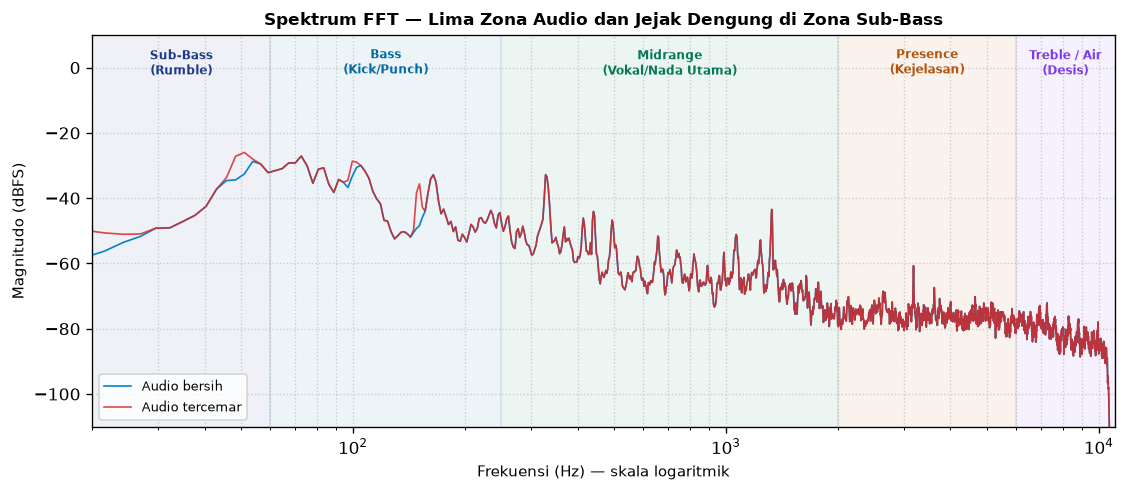

In [9]:
N_FFT_SPEC = 8192
# Dirata-ratakan lintas seluruh durasi 10 detik, bukan satu potongan tunggal
freqs, db_clean = spectrum_dbfs(y_clean, sr, n_fft=N_FFT_SPEC)
_,     db_dirty = spectrum_dbfs(y_dirty, sr, n_fft=N_FFT_SPEC)

# Lima zona spektrum audio yang menjadi acuan praktis penyetelan Equalizer
ZONA = [
    (20,   60,   'Sub-Bass\n(Rumble)',            '#1e3a8a'),
    (60,   250,  'Bass\n(Kick/Punch)',            '#0369a1'),
    (250,  2000, 'Midrange\n(Vokal/Nada Utama)',  '#047857'),
    (2000, 6000, 'Presence\n(Kejelasan)',         '#b45309'),
    (6000, 11025,'Treble / Air\n(Desis)',         '#7c3aed'),
]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for f_lo, f_hi, label, warna in ZONA:
    ax.axvspan(f_lo, f_hi, color=warna, alpha=0.07)
    ax.text(np.sqrt(f_lo * f_hi), 6, label, ha='center', va='top',
            fontsize=7, fontweight='bold', color=warna)

ax.semilogx(freqs[1:], db_clean[1:], color=C_SIGNAL, lw=1.0, label='Audio bersih')
ax.semilogx(freqs[1:], db_dirty[1:], color=C_ALERT, lw=1.0, alpha=0.85, label='Audio tercemar')

ax.set_title("Spektrum FFT — Lima Zona Audio dan Jejak Dengung di Zona Sub-Bass",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, 11025)
ax.set_ylim(-110, 10)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8)   # di kiri bawah agar tidak menimpa label zona
plt.tight_layout()
plt.show()

### 🎭 Frequency Masking: Ketika Satu Suara Menelan Suara Lain

Selain menemukan cacat, spektrum FFT dipakai untuk mendeteksi **tabrakan nada**
(*frequency masking*): dua sumber suara yang menempati pita frekuensi sama akan saling
menutupi, sehingga yang lebih lemah menjadi tidak terdengar meskipun secara teknis masih ada
di dalam rekaman.

Inilah alasan seorang *mixing engineer* memotong sedikit frekuensi gitar di sekitar
$3\text{ kHz}$ ketika vokal terdengar tenggelam — bukan karena gitarnya salah, melainkan karena
keduanya sedang berebut ruang frekuensi yang sama. Pada gambar di atas, zona *Midrange* dan
*Presence* adalah tempat perebutan tersebut paling sering terjadi.

### 🕵️ Forensik Dengung: Puncak Tertinggi Bukanlah Nada Dasar

Sekarang kita cari dengungnya secara otomatis dengan membandingkan spektrum tercemar terhadap
spektrum bersih. Namun ada satu jebakan penalaran yang harus dihindari.

Naluri pertama kita adalah mengambil **puncak kenaikan energi tertinggi** lalu menyebutnya sebagai
frekuensi dengung. Cara ini **keliru**. Besarnya kenaikan dB pada suatu frekuensi bergantung pada
seberapa ramai musik di frekuensi tersebut: jika musik kebetulan sepi di sekitar $150\text{ Hz}$,
maka harmonik ke-3 yang lemah pun akan tampak melonjak tinggi — jauh lebih mencolok daripada nada
dasarnya sendiri yang tertutup dentuman bass.

Penalaran yang benar mengikuti sifat fisis dengung listrik: ia selalu muncul sebagai
**keluarga harmonik**, yaitu satu nada dasar beserta kelipatan bulatnya. Karena itu:

> **Nada dasar adalah anggota dengan frekuensi terendah dalam keluarga tersebut,
> bukan anggota yang puncaknya tertinggi.**

Sel berikut menerapkan penalaran itu: kumpulkan semua puncak mencurigakan, ambil yang terendah
sebagai nada dasar, lalu buktikan bahwa sisanya memang kelipatan bulatnya.

🔎 HASIL FORENSIK FREKUENSI
   Resolusi analisis (Δf) : 2.69 Hz per bin
   Puncak mencurigakan    : 3 buah (kenaikan > 4 dB)

        48.4 Hz -> naik   7.2 dB
        99.6 Hz -> naik   4.6 dB
       150.7 Hz -> naik  12.8 dB

   Puncak tertinggi       : 150.7 Hz  <- menyesatkan!
   Nada dasar (terendah)  : 48.4 Hz
   Kesimpulan             : dengung jala listrik 50 Hz

   Uji keluarga harmonik (kelipatan bulat dari 50 Hz?):
        48.4 Hz = 0.97 × 50 Hz  ✅ harmonik ke-1
        99.6 Hz = 1.99 × 50 Hz  ✅ harmonik ke-2
       150.7 Hz = 3.01 × 50 Hz  ✅ harmonik ke-3


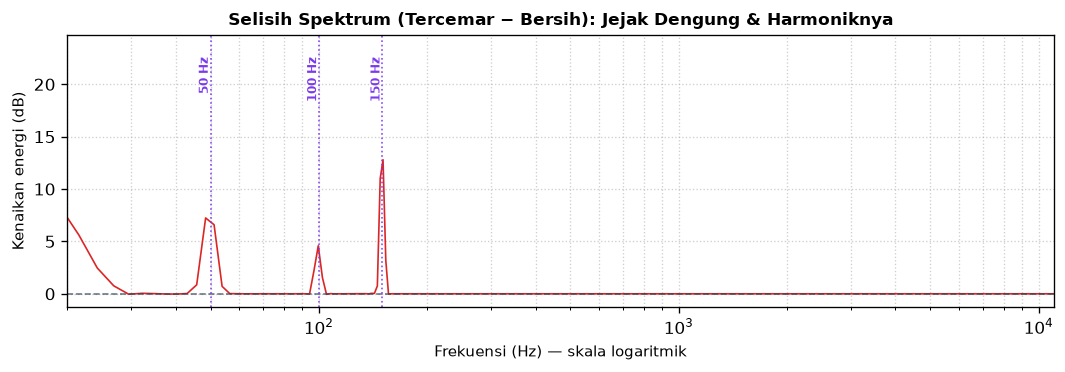

In [10]:
from scipy.signal import find_peaks

# Forensik: bandingkan spektrum tercemar terhadap spektrum bersih, lalu cari
# puncak kenaikan energi pada zona sub-bass & bass.
selisih_db = db_dirty - db_clean
zona_cari = (freqs > 30) & (freqs < 400)
idx_zona = np.where(zona_cari)[0]

AMBANG_DB = 4.0                                   # kenaikan minimum agar dianggap mencurigakan
jarak_bin = int(20 / (sr / N_FFT_SPEC))           # puncak berjarak minimal ~20 Hz
puncak, _ = find_peaks(selisih_db[idx_zona], height=AMBANG_DB, distance=jarak_bin)
f_puncak = freqs[idx_zona[puncak]]

print("🔎 HASIL FORENSIK FREKUENSI")
print(f"   Resolusi analisis (Δf) : {sr / N_FFT_SPEC:.2f} Hz per bin")
print(f"   Puncak mencurigakan    : {len(f_puncak)} buah "
      f"(kenaikan > {AMBANG_DB:.0f} dB)\n")
for f_p in f_puncak:
    print(f"     {f_p:7.1f} Hz -> naik {selisih_db[int(np.argmin(np.abs(freqs - f_p)))]:5.1f} dB")

# ⚠️ Puncak TERTINGGI belum tentu nada dasarnya. Harmonik sering tampak lebih
# menonjol hanya karena musik di sekitarnya kebetulan sepi. Nada dasar sebuah
# keluarga harmonik selalu merupakan anggota dengan frekuensi TERENDAH.
f_dasar = f_puncak.min()
f_jala = round(f_dasar / 10) * 10                 # dibulatkan ke standar jala listrik terdekat

print(f"\n   Puncak tertinggi       : "
      f"{f_puncak[np.argmax([selisih_db[int(np.argmin(np.abs(freqs - f)))] for f in f_puncak])]:.1f} Hz"
      "  <- menyesatkan!")
print(f"   Nada dasar (terendah)  : {f_dasar:.1f} Hz")
print(f"   Kesimpulan             : dengung jala listrik {f_jala:.0f} Hz\n")

# Uji harmonik diukur terhadap frekuensi jala listrik hasil pembulatan, bukan terhadap
# bin terendah. Posisi bin sendiri sudah terkuantisasi sebesar Δf, sehingga memakainya
# sebagai pembagi akan melipatgandakan galat pada harmonik yang tinggi.
print(f"   Uji keluarga harmonik (kelipatan bulat dari {f_jala:.0f} Hz?):")
for f_p in f_puncak:
    rasio = f_p / f_jala
    cocok = abs(rasio - round(rasio)) < 0.08
    print(f"     {f_p:7.1f} Hz = {rasio:4.2f} × {f_jala:.0f} Hz  "
          f"{'✅ harmonik ke-' + str(round(rasio)) if cocok else '❌ bukan harmonik'}")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.semilogx(freqs[1:], selisih_db[1:], color=C_ALERT, lw=1.0)
ax.axhline(0, color=C_NEUTRAL, lw=1.0, linestyle='--', alpha=0.7)
for k in (1, 2, 3):
    ax.axvline(50 * k, color=C_ACCENT, lw=1.0, linestyle=':', alpha=0.9)
    ax.text(50 * k, selisih_db.max() * 0.92, f"{50*k} Hz", rotation=90,
            fontsize=7, fontweight='bold', color=C_ACCENT, ha='right', va='top')

ax.set_title("Selisih Spektrum (Tercemar − Bersih): Jejak Dengung & Harmoniknya",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Kenaikan energi (dB)", fontsize=9)
ax.set_xlim(20, 11025)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Waktu–Frekuensi: Spektrogram (STFT)

### 🌡️ Peta Panas Tiga Dimensi
Waveform menampilkan waktu tetapi kehilangan frekuensi. Spektrum FFT menampilkan frekuensi
tetapi kehilangan waktu — ia hanya memberi satu potret rata-rata. **Spektrogram menyatukan
keduanya** dengan cara menggeser jendela analisis di sepanjang sinyal
(*Short-Time Fourier Transform*, STFT):

- **Sumbu X:** waktu — kapan suatu nada berbunyi.
- **Sumbu Y:** frekuensi — tinggi rendahnya nada.
- **Warna:** energi — terang berarti kuat, gelap berarti lemah.

### 👁️ Tiga Pola Visual yang Wajib Dikenali

| Pola | Penyebab |
|---|---|
| **Garis vertikal** | Transien — ketukan drum yang menyebar ke seluruh frekuensi dalam waktu singkat |
| **Garis horizontal** | Nada yang bertahan lama — dengung listrik atau not *sustain* |
| **Garis horizontal bertingkat** | Deret harmonik — satu nada musik beserta kelipatan frekuensinya |

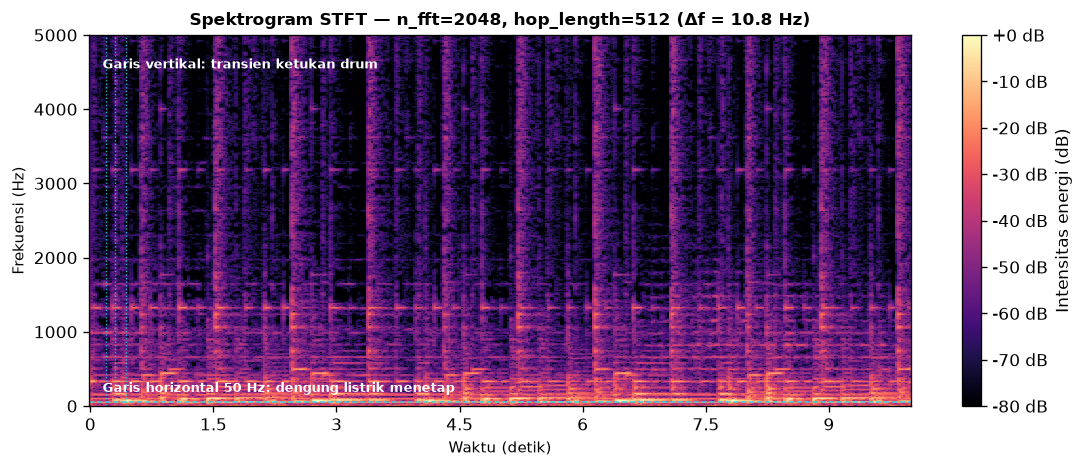

In [11]:
N_FFT, HOP = 2048, 512

S_dirty = np.abs(librosa.stft(y_dirty, n_fft=N_FFT, hop_length=HOP))
S_db = librosa.amplitude_to_db(S_dirty, ref=np.max)   # magnitudo -> amplitude_to_db

fig, ax = plt.subplots(figsize=(9.5, 4))
img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                               x_axis='time', y_axis='linear', ax=ax, cmap='magma')
ax.set_ylim(0, 5000)
ax.set_title(f"Spektrogram STFT — n_fft={N_FFT}, hop_length={HOP} "
             f"(Δf = {sr/N_FFT:.1f} Hz)", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Frekuensi (Hz)", fontsize=9)
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Intensitas energi (dB)')

# Menandai garis dengung yang menetap sepanjang durasi
ax.axhline(50, color='#22d3ee', lw=0.9, linestyle='--', alpha=0.9)
ax.text(0.15, 190, "Garis horizontal 50 Hz: dengung listrik menetap",
        color='white', fontsize=7.5, fontweight='bold')

# Menandai beberapa transien sebagai contoh garis vertikal
for ot in librosa.onset.onset_detect(y=y_clean, sr=sr, units='time')[:3]:
    ax.axvline(ot, color='#22d3ee', lw=0.8, linestyle=':', alpha=0.85)
ax.text(0.15, 4550, "Garis vertikal: transien ketukan drum",
        color='white', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

### ⚖️ Trade-off Resolusi: Tidak Ada Pilihan yang Menang di Dua Sisi

Parameter `n_fft` menentukan panjang jendela analisis, dan dari sanalah muncul dilema
paling mendasar dalam analisis waktu-frekuensi:

$$\Delta f = \frac{f_s}{n_{\text{fft}}} \qquad\qquad \text{panjang jendela} = \frac{n_{\text{fft}}}{f_s}$$

Jendela **panjang** mengamati banyak siklus gelombang sehingga frekuensi terbaca tajam — tetapi
seluruh kejadian dalam rentang waktu itu tercampur menjadi satu, sehingga transien melebar.
Jendela **pendek** melokalisasi kejadian dengan presisi — tetapi terlalu sedikit siklus yang
teramati untuk dapat memastikan frekuensinya.

Ini bukan kekurangan implementasi, melainkan **batas fisika analisis sinyal**: memperbaiki satu
sisi selalu memperburuk sisi lainnya.

 n_fft    hop    Δf (Hz)   jendela (ms)   Dengung 50 Hz terpisah?
------------------------------------------------------------------------------
   256     64       86.1           11.6   TIDAK — Δf melebihi 50 Hz
  1024    256       21.5           46.4   YA
  4096   1024        5.4          185.8   YA


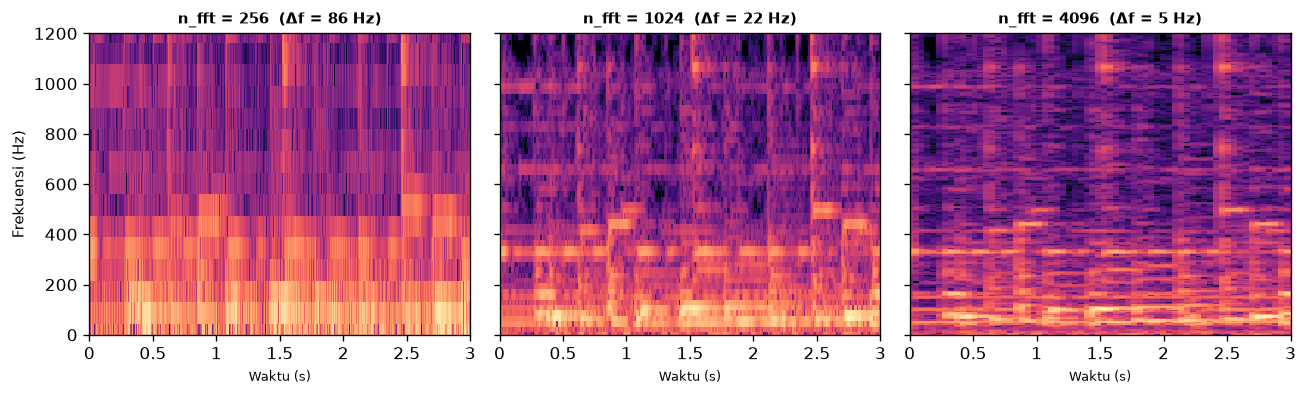


👉 Pada n_fft = 256, resolusi 86 Hz lebih kasar daripada frekuensi dengung itu sendiri,
   sehingga garis 50 Hz melebur ke dalam pita paling bawah dan hilang dari pandangan.
   Pada n_fft = 4096, garis dengung tampak tegas — namun ketukan drum menjadi kabur.


In [12]:
KONFIG = [
    (256,   64, 'Jendela pendek — transien tajam, frekuensi kabur'),
    (1024, 256, 'Kompromi umum'),
    (4096,1024, 'Jendela panjang — frekuensi tajam, transien melebar'),
]

print(f"{'n_fft':>6} {'hop':>6} {'Δf (Hz)':>10} {'jendela (ms)':>14}   Dengung 50 Hz terpisah?")
print("-" * 78)
for n_fft, hop, _ in KONFIG:
    df = sr / n_fft
    print(f"{n_fft:>6} {hop:>6} {df:>10.1f} {n_fft/sr*1000:>14.1f}   "
          f"{'YA' if df < 50 else 'TIDAK — Δf melebihi 50 Hz'}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for ax, (n_fft, hop, judul) in zip(axes, KONFIG):
    S = librosa.amplitude_to_db(
        np.abs(librosa.stft(y_dirty, n_fft=n_fft, hop_length=hop)), ref=np.max)
    librosa.display.specshow(S, sr=sr, hop_length=hop, n_fft=n_fft,
                             x_axis='time', y_axis='linear', ax=ax, cmap='magma')
    ax.set_ylim(0, 1200)
    ax.set_xlim(0, 3)
    ax.set_title(f"n_fft = {n_fft}  (Δf = {sr/n_fft:.0f} Hz)", fontsize=9, fontweight='bold')
    ax.set_xlabel("Waktu (s)", fontsize=8)
    ax.set_ylabel("")
axes[0].set_ylabel("Frekuensi (Hz)", fontsize=9)
plt.tight_layout()
plt.show()

print("\n👉 Pada n_fft = 256, resolusi 86 Hz lebih kasar daripada frekuensi dengung itu sendiri,")
print("   sehingga garis 50 Hz melebur ke dalam pita paling bawah dan hilang dari pandangan.")
print("   Pada n_fft = 4096, garis dengung tampak tegas — namun ketukan drum menjadi kabur.")

## 6. Skala Perseptual: Mel-Spektrogram

### 👂 Telinga Manusia Tidak Linier
Selisih $100\text{ Hz}$ tidak selalu terdengar sama besar. Perbedaan antara $100\text{ Hz}$ dan
$200\text{ Hz}$ terasa sejauh satu oktaf, sedangkan perbedaan antara $10.000\text{ Hz}$ dan
$10.100\text{ Hz}$ praktis tidak terdengar sama sekali. Telinga manusia sangat peka di nada
rendah dan makin tumpul di nada tinggi.

**Skala Mel** memetakan frekuensi fisik ke skala persepsi tersebut:

$$m = 2595 \log_{10}\left(1 + \frac{f}{700}\right)$$

### ⚠️ Jebakan: Rumus di Slide ≠ Bawaan librosa
Rumus di atas adalah varian **HTK**. Namun `librosa.hz_to_mel()` secara bawaan memakai varian
**Slaney**, yang memberi angka sama sekali berbeda. Keduanya sama-sama benar — keduanya hanyalah
dua konvensi kalibrasi yang berbeda untuk kurva persepsi yang sama.

Bila Anda ingin mencocokkan angka dengan rumus di slide, sebutkan `htk=True` secara eksplisit.
Sel berikut membuktikan perbedaannya agar Anda tidak mengira slide atau pustakanya keliru.

  f (Hz)    rumus slide   librosa htk=True   librosa (bawaan)
--------------------------------------------------------------
     100         150.49             150.49               1.50
     700         781.17             781.17              10.50
    1000         999.99             999.99              15.00
    4000        2146.06            2146.06              35.16
    8000        2840.02            2840.02              45.25

👉 Kolom kedua dan ketiga identik: rumus slide memang varian HTK.
   Kolom keempat (bawaan librosa) memakai varian Slaney — berbeda, tetapi tetap sahih.


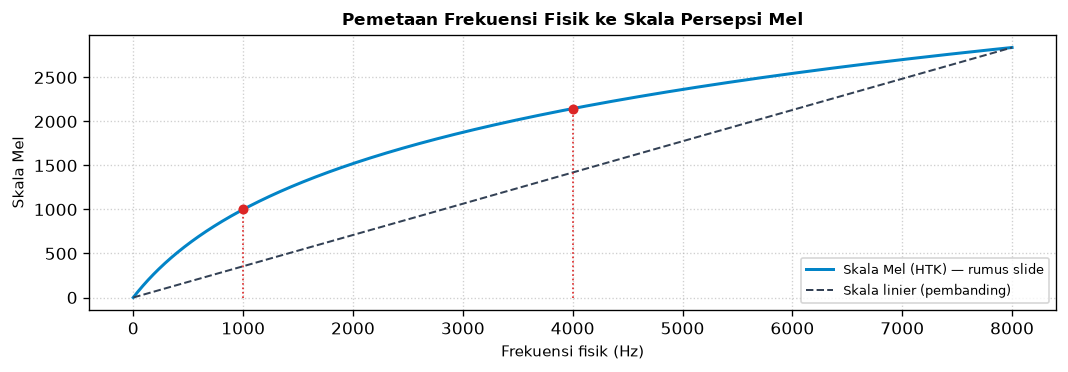


Perhatikan kurva menanjak curam di awal lalu melandai: separuh pertama sumbu Mel
dihabiskan hanya untuk beberapa ribu Hz pertama — justru daerah tempat vokal berada.


In [13]:
def mel_htk(f):
    """Skala Mel varian HTK — rumus yang tertulis pada slide perkuliahan."""
    return 2595 * np.log10(1 + np.asarray(f, dtype=float) / 700)


print(f"{'f (Hz)':>8} {'rumus slide':>14} {'librosa htk=True':>18} {'librosa (bawaan)':>18}")
print("-" * 62)
for f_uji_hz in (100, 700, 1000, 4000, 8000):
    print(f"{f_uji_hz:>8} {mel_htk(f_uji_hz):>14.2f} "
          f"{librosa.hz_to_mel(f_uji_hz, htk=True):>18.2f} "
          f"{librosa.hz_to_mel(f_uji_hz):>18.2f}")

print("\n👉 Kolom kedua dan ketiga identik: rumus slide memang varian HTK.")
print("   Kolom keempat (bawaan librosa) memakai varian Slaney — berbeda, tetapi tetap sahih.")

f_plot = np.linspace(0, 8000, 1000)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(f_plot, mel_htk(f_plot), color=C_SIGNAL, lw=1.8, label='Skala Mel (HTK) — rumus slide')
ax.plot(f_plot, f_plot * mel_htk(8000) / 8000, color=C_NEUTRAL, lw=1.2,
        linestyle='--', label='Skala linier (pembanding)')

for f_mark in (1000, 4000):
    ax.plot([f_mark, f_mark], [0, mel_htk(f_mark)], color=C_ALERT, lw=1.0, linestyle=':')
    ax.plot(f_mark, mel_htk(f_mark), 'o', color=C_ALERT, ms=5)

ax.set_title("Pemetaan Frekuensi Fisik ke Skala Persepsi Mel", fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi fisik (Hz)", fontsize=9)
ax.set_ylabel("Skala Mel", fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nPerhatikan kurva menanjak curam di awal lalu melandai: separuh pertama sumbu Mel")
print("dihabiskan hanya untuk beberapa ribu Hz pertama — justru daerah tempat vokal berada.")

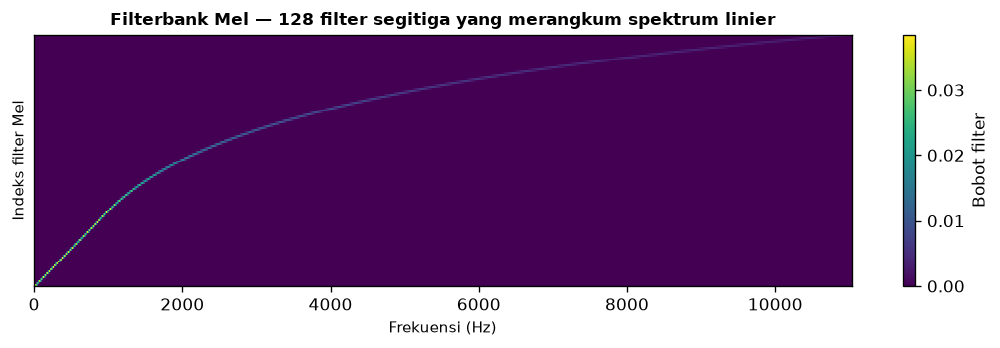

Filter Mel makin melebar seiring naiknya frekuensi:
  filter ke-1    berpusat di     26.2 Hz  (lebar ≈   52.4 Hz)
  filter ke-10   berpusat di    262.0 Hz  (lebar ≈   52.4 Hz)
  filter ke-40   berpusat di   1050.7 Hz  (lebar ≈   56.8 Hz)
  filter ke-80   berpusat di   3096.5 Hz  (lebar ≈  167.3 Hz)
  filter ke-120  berpusat di   9125.1 Hz  (lebar ≈  493.2 Hz)


In [14]:
N_MELS = 128
mel_fb = librosa.filters.mel(sr=sr, n_fft=N_FFT, n_mels=N_MELS)

fig, ax = plt.subplots(figsize=(9, 3))
img = librosa.display.specshow(mel_fb, sr=sr, n_fft=N_FFT, x_axis='linear', ax=ax, cmap='viridis')
ax.set_title(f"Filterbank Mel — {N_MELS} filter segitiga yang merangkum spektrum linier",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz)", fontsize=9)
ax.set_ylabel("Indeks filter Mel", fontsize=9)
fig.colorbar(img, ax=ax, label='Bobot filter')
plt.tight_layout()
plt.show()

mel_f = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=sr / 2)
print(f"Filter Mel makin melebar seiring naiknya frekuensi:")
for i in (1, 10, 40, 80, 120):
    print(f"  filter ke-{i:<4} berpusat di {mel_f[i]:8.1f} Hz  "
          f"(lebar ≈ {mel_f[i+1]-mel_f[i-1]:6.1f} Hz)")

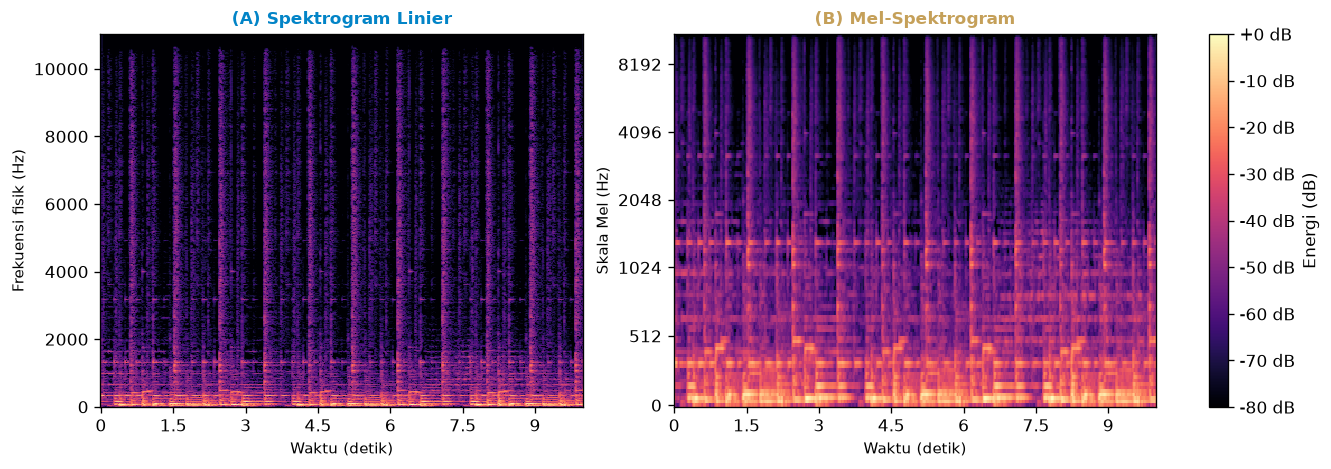

(A) Frekuensi tinggi yang jarang dipakai justru memakan porsi ruang terbanyak.
(B) Daerah vokal di bawah 1 kHz diperbesar, sehingga pola artikulasi jauh lebih kontras.
Dimensi spektrogram linier :  1025 bin frekuensi × 431 bingkai waktu
Dimensi Mel-spektrogram    :   128 bin Mel       × 431 bingkai waktu

Pemampatan data: 8.0× lebih ringkas, namun informasi
perseptual yang penting justru dipertahankan. Inilah alasan model AI audio seperti
OpenAI Whisper memakai Mel-spektrogram sebagai masukan, bukan spektrogram linier.


In [15]:
S_lin = librosa.amplitude_to_db(
    np.abs(librosa.stft(y_clean, n_fft=N_FFT, hop_length=HOP)), ref=np.max)

# Dua hal yang mudah keliru di sel ini:
#  1. melspectrogram mengembalikan POWER (power=2.0 bawaan) -> wajib power_to_db,
#     bukan amplitude_to_db seperti pada magnitudo STFT di atas.
#  2. Filterbank di bawah memakai skala Mel varian Slaney (bawaan librosa), bukan
#     varian HTK pada rumus slide. Sumbu 'mel' pada specshow mengikuti konvensi
#     yang sama, sehingga gambar dan perhitungan tetap konsisten satu sama lain.
S_mel = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_fft=N_FFT,
                                       hop_length=HOP, n_mels=N_MELS)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

librosa.display.specshow(S_lin, sr=sr, hop_length=HOP, n_fft=N_FFT,
                         x_axis='time', y_axis='linear', ax=axes[0], cmap='magma')
axes[0].set_title("(A) Spektrogram Linier", fontsize=10, fontweight='bold', color=C_SIGNAL)
axes[0].set_ylabel("Frekuensi fisik (Hz)", fontsize=9)

img1 = librosa.display.specshow(S_mel_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                                x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
axes[1].set_title("(B) Mel-Spektrogram", fontsize=10, fontweight='bold', color=C_GOLD)
axes[1].set_ylabel("Skala Mel (Hz)", fontsize=9)

for ax in axes:
    ax.set_xlabel("Waktu (detik)", fontsize=9)
fig.colorbar(img1, ax=axes, format='%+2.0f dB', label='Energi (dB)')
plt.show()

print("(A) Frekuensi tinggi yang jarang dipakai justru memakan porsi ruang terbanyak.")
print("(B) Daerah vokal di bawah 1 kHz diperbesar, sehingga pola artikulasi jauh lebih kontras.")

print(f"Dimensi spektrogram linier : {S_lin.shape[0]:>5} bin frekuensi × {S_lin.shape[1]} bingkai waktu")
print(f"Dimensi Mel-spektrogram    : {S_mel_db.shape[0]:>5} bin Mel       × {S_mel_db.shape[1]} bingkai waktu")
print(f"\nPemampatan data: {S_lin.shape[0] / S_mel_db.shape[0]:.1f}× lebih ringkas, namun informasi")
print("perseptual yang penting justru dipertahankan. Inilah alasan model AI audio seperti")
print("OpenAI Whisper memakai Mel-spektrogram sebagai masukan, bukan spektrogram linier.")

## 7. Tampilan Equalizer Modern (RTA + Kurva Filter)

### 🎛️ Dua Lapis dalam Satu Layar
Pada perangkat lunak studio dan mixer digital modern, layar *Equalizer* menampilkan dua hal
sekaligus yang saling ditumpuk:

1. **Latar RTA** (*Real-Time Analyzer*) — spektrum frekuensi audio yang sedang berbunyi saat itu,
   digambar sebagai bidang terisi. Inilah "yang sedang terjadi".
2. **Kurva EQ** — garis respons filter yang sedang dirancang, lengkap dengan titik kontrol
   (*node*) yang dapat digeser. Inilah "yang kita inginkan".

Teknisi bekerja dengan membaca lapisan pertama, lalu menggeser lapisan kedua sebagai responsnya.

### 📌 Catatan Cakupan
Bagian ini **hanya menggambar tampilan antarmukanya** — kurva yang ditampilkan adalah
*kurva respons target*, yaitu bentuk matematis yang kita inginkan. Perancangan filter digital
yang sesungguhnya (`scipy.signal.butter`, `sosfilt`, `iirnotch`) beserta penerapannya ke audio
adalah materi **Modul 03**. Di sini belum ada satu pun sampel audio yang difilter.

### 🎚️ Empat Node yang Akan Digambar

| Node | Jenis | Frekuensi | Tujuan praktis |
|---|---|---|---|
| 1 | High-Pass | $80\text{ Hz}$ | Membuang gemuruh mikrofon |
| 2 | Bell Cut $-4\text{ dB}$ | $300\text{ Hz}$ | Meredam suara menggema (*muddy*) |
| 3 | Bell Boost $+5\text{ dB}$ | $3\text{ kHz}$ | Mendongkrak kejelasan vokal |
| 4 | High Shelf $+3\text{ dB}$ | $10\text{ kHz}$ | Menambah kilau treble (*air*) |

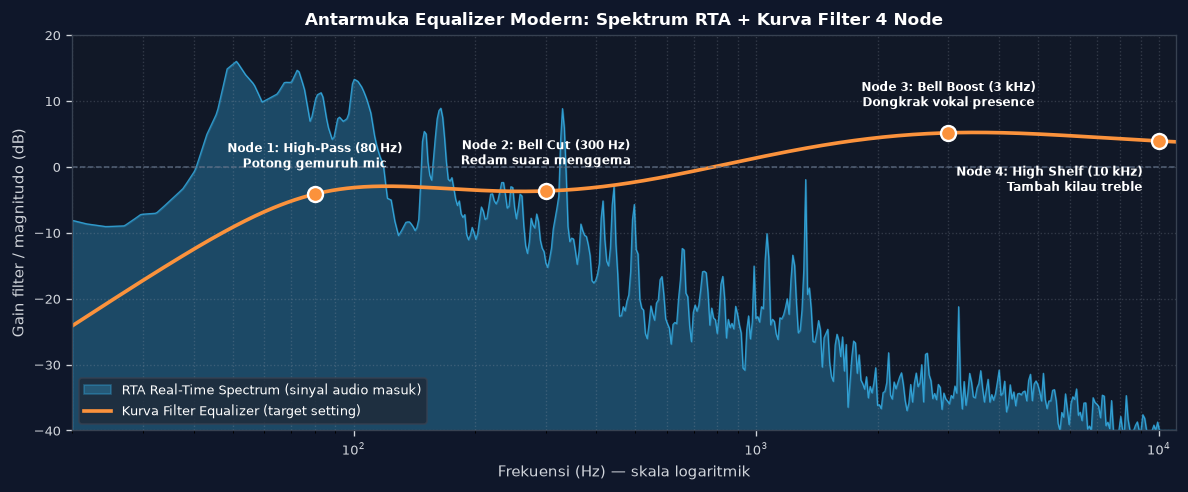

Nilai kurva EQ pada beberapa frekuensi acuan:
      30 Hz -> -17.21 dB
      80 Hz ->  -4.14 dB
     300 Hz ->  -3.67 dB
    1000 Hz ->  +1.36 dB
    3000 Hz ->  +5.16 dB
   10000 Hz ->  +3.92 dB


In [16]:
def gain_highpass(f, fc, order=2):
    """Bentuk respons high-pass Butterworth (kurva target, bukan filter yang dirancang)."""
    r = (f / fc) ** (2 * order)
    return 10 * np.log10(r / (1 + r))


def gain_bell(f, fc, gain_db, q):
    """Bentuk respons bell/peaking: puncak atau lembah di sekitar fc."""
    return gain_db * np.exp(-0.5 * (np.log(f / fc) * q) ** 2)


def gain_highshelf(f, fc, gain_db):
    """Bentuk respons high-shelf: penguatan bertahap di atas fc."""
    return gain_db / (1 + (fc / f) ** 2)


NODES = [
    ('Node 1: High-Pass (80 Hz)',      'Potong gemuruh mic',        80.0,   None),
    ('Node 2: Bell Cut (300 Hz)',      'Redam suara menggema',      300.0,  -4.0),
    ('Node 3: Bell Boost (3 kHz)',     'Dongkrak vokal presence',   3000.0, +5.0),
    ('Node 4: High Shelf (10 kHz)',    'Tambah kilau treble',       10000.0, +3.0),
]

f_eq = np.logspace(np.log10(20), np.log10(11025), 600)
kurva_eq = (gain_highpass(f_eq, 80)
            + gain_bell(f_eq, 300, -4.0, 1.2)
            + gain_bell(f_eq, 3000, +5.0, 1.0)
            + gain_highshelf(f_eq, 10000, +3.0))

# Spektrum RTA: dipetakan ke sumbu kurva EQ, lalu digeser agar puncaknya berhenti
# tepat di bawah plafon grafik sehingga bentuk spektrum tetap utuh terbaca.
rta_db = np.interp(f_eq, freqs[1:], db_dirty[1:])
rta_plot = np.clip(rta_db - rta_db.max() + 16, -40, 20)

fig, ax = plt.subplots(figsize=(10, 4.2))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#111827')

ax.fill_between(f_eq, -40, rta_plot, color='#38bdf8', alpha=0.30,
                label='RTA Real-Time Spectrum (sinyal audio masuk)')
ax.semilogx(f_eq, rta_plot, color='#38bdf8', lw=0.8, alpha=0.7)
ax.semilogx(f_eq, kurva_eq, color='#fb923c', lw=2.2,
            label='Kurva Filter Equalizer (target setting)')
ax.axhline(0, color='#64748b', lw=0.9, linestyle='--', alpha=0.8)

for idx, (nama, tujuan, fc, _) in enumerate(NODES):
    g = np.interp(fc, f_eq, kurva_eq)
    ax.plot(fc, g, 'o', color='#fb923c', ms=9, mec='white', mew=1.4, zorder=5)
    # Node terakhir berada di tepi kanan grafik: labelnya dirata-kanan agar tidak
    # terpotong batas gambar, dan diletakkan di bawah marker agar tidak bertabrakan
    # dengan label Node 3 yang berdekatan.
    terakhir = idx == len(NODES) - 1
    ha = 'right' if terakhir else 'center'
    ax.annotate(f"{nama}\n{tujuan}", xy=(fc, g),
                xytext=(-10, -30) if terakhir else (0, 16),
                textcoords='offset points', ha=ha,
                fontsize=7, fontweight='bold', color='white')

ax.set_title("Antarmuka Equalizer Modern: Spektrum RTA + Kurva Filter 4 Node",
             fontsize=10, fontweight='bold', color='white')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9, color='#d1d5db')
ax.set_ylabel("Gain filter / magnitudo (dB)", fontsize=9, color='#d1d5db')
ax.set_xlim(20, 11025)
ax.set_ylim(-40, 20)
ax.tick_params(colors='#d1d5db', labelsize=8)
for spine in ax.spines.values():
    spine.set_color('#374151')
ax.grid(True, which='both', linestyle=':', alpha=0.25, color='#9ca3af')
leg = ax.legend(loc='lower left', fontsize=8, facecolor='#1f2937', edgecolor='#374151')
for txt in leg.get_texts():
    txt.set_color('white')
plt.tight_layout()
plt.show()

print("Nilai kurva EQ pada beberapa frekuensi acuan:")
for f_probe in (30, 80, 300, 1000, 3000, 10000):
    print(f"  {f_probe:>6} Hz -> {np.interp(f_probe, f_eq, kurva_eq):+6.2f} dB")

## 8. Galeri Komparasi: Satu Berkas, Empat Dimensi Visual

Seluruh panel di bawah ini berasal dari **berkas audio yang sama persis**. Yang berbeda hanyalah
sudut pandangnya. Perhatikan bahwa setiap tampilan menonjolkan sesuatu yang tidak terlihat
pada tampilan lainnya — itulah sebabnya seorang teknisi multimedia selalu berpindah-pindah
antar tampilan, bukan bertahan pada satu saja.

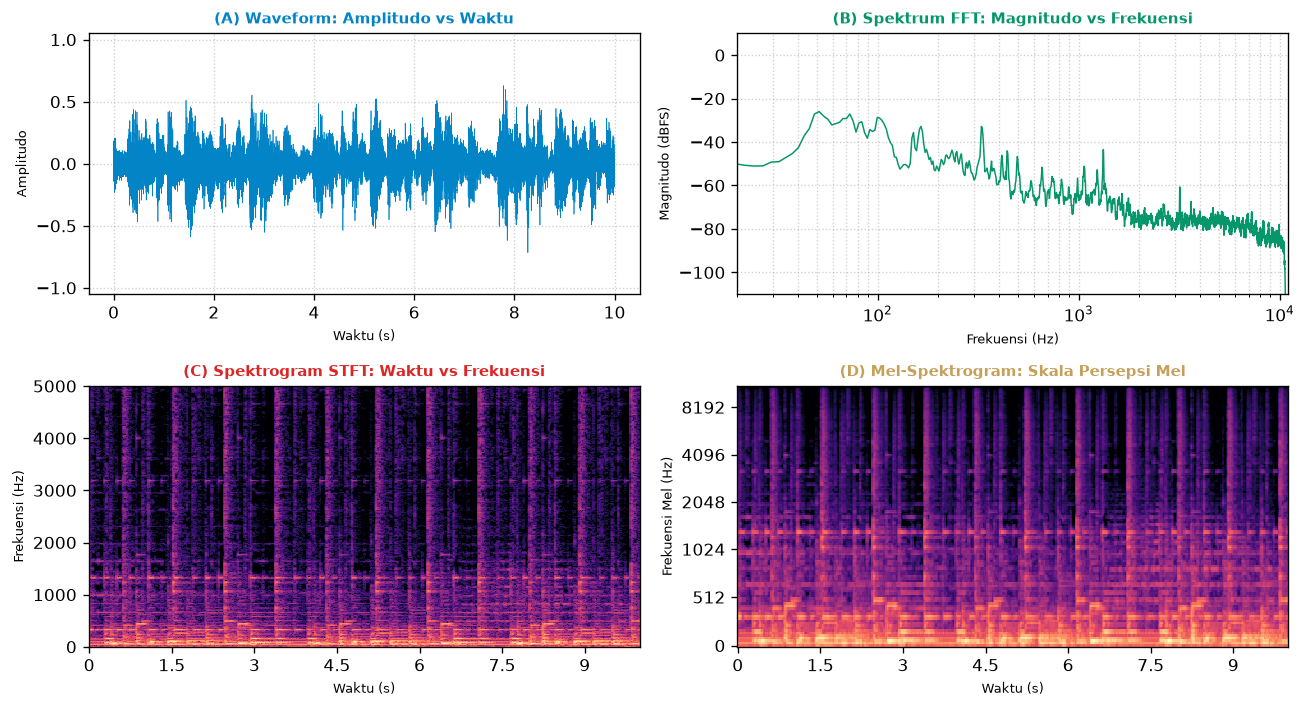

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

# (A) Waveform
axes[0, 0].plot(t, y_dirty, color=C_SIGNAL, lw=0.4)
axes[0, 0].set_title("(A) Waveform: Amplitudo vs Waktu", fontsize=9,
                     fontweight='bold', color=C_SIGNAL)
axes[0, 0].set_xlabel("Waktu (s)", fontsize=8)
axes[0, 0].set_ylabel("Amplitudo", fontsize=8)
axes[0, 0].set_ylim(-1.05, 1.05)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# (B) Spektrum FFT
axes[0, 1].semilogx(freqs[1:], db_dirty[1:], color=C_GOOD, lw=0.9)
axes[0, 1].set_title("(B) Spektrum FFT: Magnitudo vs Frekuensi", fontsize=9,
                     fontweight='bold', color=C_GOOD)
axes[0, 1].set_xlabel("Frekuensi (Hz)", fontsize=8)
axes[0, 1].set_ylabel("Magnitudo (dBFS)", fontsize=8)
axes[0, 1].set_xlim(20, 11025)
axes[0, 1].set_ylim(-110, 10)
axes[0, 1].grid(True, which='both', linestyle=':', alpha=0.6)

# (C) Spektrogram STFT
librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                         x_axis='time', y_axis='linear', ax=axes[1, 0], cmap='magma')
axes[1, 0].set_ylim(0, 5000)
axes[1, 0].set_title("(C) Spektrogram STFT: Waktu vs Frekuensi", fontsize=9,
                     fontweight='bold', color=C_ALERT)
axes[1, 0].set_xlabel("Waktu (s)", fontsize=8)
axes[1, 0].set_ylabel("Frekuensi (Hz)", fontsize=8)

# (D) Mel-spektrogram
S_mel_dirty = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y_dirty, sr=sr, n_fft=N_FFT,
                                   hop_length=HOP, n_mels=N_MELS), ref=np.max)
librosa.display.specshow(S_mel_dirty, sr=sr, hop_length=HOP, n_fft=N_FFT,
                         x_axis='time', y_axis='mel', ax=axes[1, 1], cmap='magma')
axes[1, 1].set_title("(D) Mel-Spektrogram: Skala Persepsi Mel", fontsize=9,
                     fontweight='bold', color=C_GOLD)
axes[1, 1].set_xlabel("Waktu (s)", fontsize=8)
axes[1, 1].set_ylabel("Frekuensi Mel (Hz)", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Panduan Memilih Tampilan Audio

| Tampilan | Sumbu X / Y | Kekuatan utama | Kapan digunakan? |
|---|---|---|---|
| **Waveform** | Waktu / Amplitudo | Dinamika volume & deteksi clipping | Pemotongan durasi, *fade in/out*, penyelarasan tempo |
| **Spektrum FFT** | Frekuensi / dBFS | Deteksi nada & duri dengung | Menyetel titik frekuensi *Equalizer* |
| **Spektrogram** | Waktu / Frekuensi (warna) | Jejak harmonik & transien | Restorasi audio, forensik derau |
| **Mel-Spektrogram** | Waktu / Mel (warna) | Meniru pendengaran manusia | Model AI vokal, Whisper, ASR |
| **RTA + EQ** | Frekuensi / dB (langsung) | Kurva filter di atas spektrum | *Mixing* interaktif & konser *live* |

### 💡 Intisari
Dalam sistem multimedia profesional **tidak ada satu tampilan yang berdiri sendiri**. Setiap
tampilan adalah hasil pertukaran: apa yang dipertajam pada satu sumbu selalu dibayar dengan
kekaburan pada sumbu lainnya. Alur kerja yang matang selalu menggabungkan waveform untuk
penataan waktu dan spektrum/RTA untuk pembedahan frekuensi.

---

## 10. Latihan & Pembahasan

Tiga latihan berikut menguji kemampuan Anda **membaca dan menghasilkan** representasi visual.
Kerjakan sel latihan terlebih dahulu, baru bandingkan dengan sel pembahasan di bawahnya.

### 📝 Latihan 1 — Forensik Dengung

Sel di bawah membangkitkan sebuah sinyal misterius yang telah tercemar dengung pada frekuensi
yang **dirahasiakan**. Tugas Anda:

1. Hitung spektrum dBFS sinyal tersebut menggunakan fungsi `spectrum_dbfs()`.
2. Cari frekuensi puncak tertinggi pada rentang sub-bass hingga bass ($20$–$400\text{ Hz}$).
3. Laporkan frekuensi dengung dalam Hz, dan tentukan apakah rekaman ini berasal dari negara
   berstandar jala listrik $50\text{ Hz}$ (Indonesia/Eropa) atau $60\text{ Hz}$ (Amerika Serikat).

> 💡 **Petunjuk:** gunakan *masking* NumPy untuk membatasi pencarian ke rentang frekuensi yang
> diminta, lalu `np.argmax` untuk menemukan indeks puncaknya.

In [18]:
# --- Sinyal misterius (jangan mengintip nilainya!) -----------------------
_rng_soal = np.random.default_rng(1)
_f_rahasia = float(_rng_soal.choice([50.0, 60.0]))
N_SOAL = 8192
_t_soal = np.arange(N_SOAL) / SR
y_misteri = (y_clean[:N_SOAL]
             + 0.08 * np.sin(2 * np.pi * _f_rahasia * _t_soal)
             + 0.03 * np.sin(2 * np.pi * 2 * _f_rahasia * _t_soal))
# ------------------------------------------------------------------------

print(f"Sinyal misterius siap: {len(y_misteri)} sampel @ {SR} Hz")

# TODO 1: hitung spektrum dBFS dari y_misteri
# f_m, db_m = ...

# TODO 2: batasi pencarian ke rentang 20-400 Hz, lalu temukan frekuensi puncaknya
# f_dengung = ...

# TODO 3: cetak kesimpulan Anda

Sinyal misterius siap: 8192 sampel @ 22050 Hz


### ✅ Pembahasan Latihan 1

Kuncinya adalah membatasi pencarian **sebelum** memanggil `np.argmax`. Tanpa pembatasan, puncak
tertinggi hampir pasti jatuh pada energi musik di rentang *midrange*, bukan pada dengungnya.

Perhatikan juga bahwa `np.argmax` mengembalikan indeks **relatif terhadap array yang dipotong**,
sehingga indeks tersebut perlu dipetakan kembali ke array frekuensi aslinya.

Resolusi analisis (Δf) : 2.69 Hz per bin
Frekuensi puncak        : 51.14 Hz (-23.1 dBFS)
Kesimpulan              : dengung jala listrik 50 Hz
Asal rekaman            : Indonesia / Eropa

Verifikasi — frekuensi yang sebenarnya disuntikkan: 50 Hz ✅ TEPAT


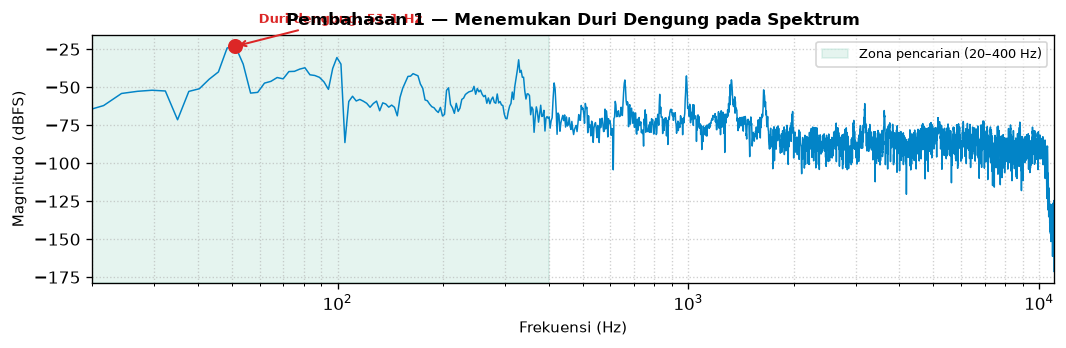

In [19]:
f_m, db_m = spectrum_dbfs(y_misteri, SR, n_fft=N_SOAL)

# Batasi pencarian ke zona sub-bass & bass, lalu petakan indeks kembali ke array asli
mask = (f_m >= 20) & (f_m <= 400)
idx_kandidat = np.where(mask)[0]
i_puncak = idx_kandidat[np.argmax(db_m[mask])]
f_dengung = f_m[i_puncak]

standar = 50 if abs(f_dengung - 50) < abs(f_dengung - 60) else 60

print(f"Resolusi analisis (Δf) : {SR / N_SOAL:.2f} Hz per bin")
print(f"Frekuensi puncak        : {f_dengung:.2f} Hz ({db_m[i_puncak]:.1f} dBFS)")
print(f"Kesimpulan              : dengung jala listrik {standar} Hz")
print(f"Asal rekaman            : {'Indonesia / Eropa' if standar == 50 else 'Amerika Serikat'}")
print(f"\nVerifikasi — frekuensi yang sebenarnya disuntikkan: {_f_rahasia:.0f} Hz "
      f"{'✅ TEPAT' if standar == _f_rahasia else '❌ MELESET'}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogx(f_m[1:], db_m[1:], color=C_SIGNAL, lw=0.9)
ax.axvspan(20, 400, color=C_GOOD, alpha=0.10, label='Zona pencarian (20–400 Hz)')
ax.plot(f_dengung, db_m[i_puncak], 'o', color=C_ALERT, ms=8)
ax.annotate(f"Duri dengung: {f_dengung:.1f} Hz", xy=(f_dengung, db_m[i_puncak]),
            xytext=(14, 14), textcoords='offset points', fontsize=8,
            fontweight='bold', color=C_ALERT,
            arrowprops=dict(arrowstyle='->', color=C_ALERT, lw=1.2))
ax.set_title("Pembahasan 1 — Menemukan Duri Dengung pada Spektrum", fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz)", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, 11025)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### 📝 Latihan 2 — Trade-off Resolusi STFT

Sel berikut membangkitkan sinyal uji yang memuat **dua tantangan yang saling bertentangan**:
- dua nada yang berdekatan, yaitu $1000\text{ Hz}$ dan $1040\text{ Hz}$ (berjarak hanya $40\text{ Hz}$);
- satu klik transien yang sangat singkat, berdurasi $5\text{ ms}$.

Tugas Anda:

1. Untuk setiap `n_fft` pada daftar `[256, 512, 1024, 2048, 4096]`, hitung resolusi frekuensi
   $\Delta f = f_s / n_{\text{fft}}$ dan panjang jendela $n_{\text{fft}} / f_s$ dalam milidetik.
2. Tentukan `n_fft` **terkecil** yang mampu memisahkan kedua nada. Gunakan kriteria
   $\Delta f < 20\text{ Hz}$, yaitu setengah dari jarak antar nada.
3. Tentukan `n_fft` **terbesar** yang jendelanya masih lebih pendek daripada $15\text{ ms}$
   (tiga kali durasi klik), sehingga klik masih terlokalisasi dengan baik.
4. Jelaskan mengapa tidak ada satu nilai `n_fft` pun yang memenuhi kedua syarat sekaligus.

In [20]:
# --- Sinyal uji: dua nada berdekatan + satu klik transien ---------------
DUR_UJI = 1.0
t_uji2 = np.arange(int(DUR_UJI * SR)) / SR
y_uji = (0.35 * np.sin(2 * np.pi * 1000 * t_uji2)
         + 0.35 * np.sin(2 * np.pi * 1040 * t_uji2))

KLIK_T, KLIK_MS = 0.5, 5.0
i_klik = int(KLIK_T * SR)
n_klik = int(KLIK_MS / 1000 * SR)
y_uji[i_klik:i_klik + n_klik] += 0.9 * np.hanning(n_klik)
# ------------------------------------------------------------------------

JARAK_NADA_HZ = 40.0     # 1040 Hz - 1000 Hz
print(f"Jarak dua nada : {JARAK_NADA_HZ:.0f} Hz")
print(f"Durasi klik    : {KLIK_MS:.0f} ms")
print("🎵 Dengarkan: dua nada yang berdekatan terdengar sebagai getaran 'wah-wah', "
      "lalu ada satu klik di tengah.")
display(ipd.Audio(y_uji, rate=SR))

# TODO 1: untuk tiap n_fft, hitung Δf dan panjang jendela (ms)
# TODO 2: cari n_fft terkecil dengan Δf < 20 Hz
# TODO 3: cari n_fft terbesar dengan panjang jendela < 15 ms
# TODO 4: tuliskan kesimpulan Anda

Jarak dua nada : 40 Hz
Durasi klik    : 5 ms
🎵 Dengarkan: dua nada yang berdekatan terdengar sebagai getaran 'wah-wah', lalu ada satu klik di tengah.


### ✅ Pembahasan Latihan 2

Kedua syarat menarik `n_fft` ke arah yang **berlawanan**: memisahkan nada menuntut jendela
panjang, sedangkan melokalisasi klik menuntut jendela pendek. Tabel di bawah memperlihatkan
bahwa himpunan solusi keduanya tidak pernah beririsan.

 n_fft    Δf (Hz)   jendela (ms)   pisah nada?   klik tajam?
--------------------------------------------------------------
   256       86.1           11.6         tidak            YA
   512       43.1           23.2         tidak         tidak
  1024       21.5           46.4         tidak         tidak
  2048       10.8           92.9            YA         tidak
  4096        5.4          185.8            YA         tidak

n_fft terkecil yang memisahkan dua nada  : 2048
n_fft terbesar yang melokalisasi klik    : 256
Beririsan? TIDAK — kedua syarat mustahil dipenuhi bersamaan


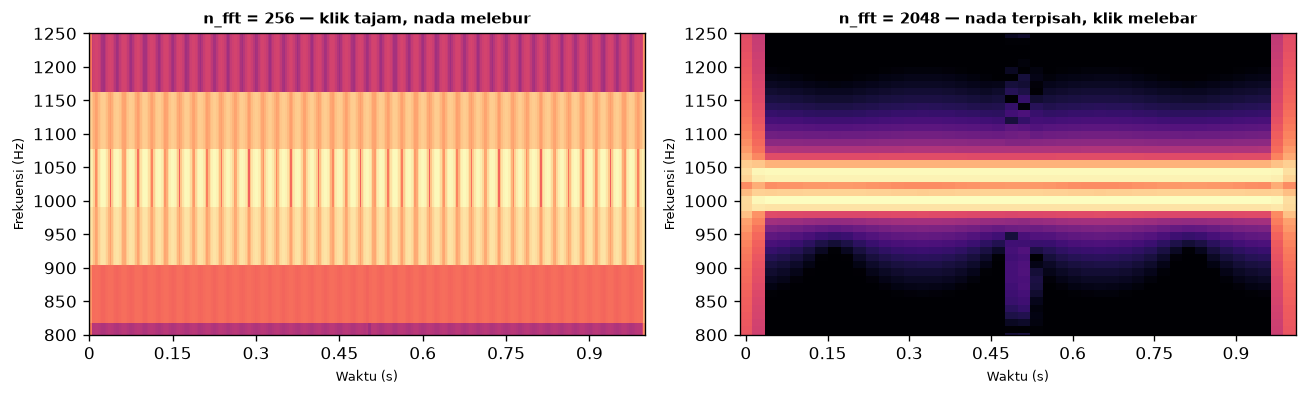


👉 Kesimpulan: ini bukan kekurangan pustaka atau komputer, melainkan batas fisika
   analisis sinyal. Untuk memastikan sebuah frekuensi, kita harus mengamati
   gelombangnya cukup lama — dan pengamatan yang lama itu sendirilah yang membuat
   posisi waktu suatu kejadian menjadi kabur.


In [21]:
KANDIDAT = [256, 512, 1024, 2048, 4096]
SYARAT_DF_HZ = JARAK_NADA_HZ / 2      # 20 Hz
SYARAT_WIN_MS = KLIK_MS * 3           # 15 ms

print(f"{'n_fft':>6} {'Δf (Hz)':>10} {'jendela (ms)':>14} {'pisah nada?':>13} {'klik tajam?':>13}")
print("-" * 62)
lolos_nada, lolos_klik = [], []
for n_fft in KANDIDAT:
    df = SR / n_fft
    win_ms = n_fft / SR * 1000
    ok_nada = df < SYARAT_DF_HZ
    ok_klik = win_ms < SYARAT_WIN_MS
    lolos_nada.append(ok_nada)
    lolos_klik.append(ok_klik)
    print(f"{n_fft:>6} {df:>10.1f} {win_ms:>14.1f} "
          f"{'YA' if ok_nada else 'tidak':>13} {'YA' if ok_klik else 'tidak':>13}")

n_pisah = min(n for n, ok in zip(KANDIDAT, lolos_nada) if ok)
n_tajam = max(n for n, ok in zip(KANDIDAT, lolos_klik) if ok)
print(f"\nn_fft terkecil yang memisahkan dua nada  : {n_pisah}")
print(f"n_fft terbesar yang melokalisasi klik    : {n_tajam}")
print(f"Beririsan? {'YA' if n_pisah <= n_tajam else 'TIDAK — kedua syarat mustahil dipenuhi bersamaan'}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, n_fft, judul in (
    (axes[0], n_tajam, f"n_fft = {n_tajam} — klik tajam, nada melebur"),
    (axes[1], n_pisah, f"n_fft = {n_pisah} — nada terpisah, klik melebar"),
):
    hop = n_fft // 4
    S = librosa.amplitude_to_db(
        np.abs(librosa.stft(y_uji, n_fft=n_fft, hop_length=hop)), ref=np.max)
    librosa.display.specshow(S, sr=SR, hop_length=hop, n_fft=n_fft,
                             x_axis='time', y_axis='linear', ax=ax, cmap='magma')
    ax.set_ylim(800, 1250)
    ax.set_title(judul, fontsize=9, fontweight='bold')
    ax.set_xlabel("Waktu (s)", fontsize=8)
    ax.set_ylabel("Frekuensi (Hz)", fontsize=8)
plt.tight_layout()
plt.show()

print("\n👉 Kesimpulan: ini bukan kekurangan pustaka atau komputer, melainkan batas fisika")
print("   analisis sinyal. Untuk memastikan sebuah frekuensi, kita harus mengamati")
print("   gelombangnya cukup lama — dan pengamatan yang lama itu sendirilah yang membuat")
print("   posisi waktu suatu kejadian menjadi kabur.")

### 📝 Latihan 3 — Membuktikan Klaim Skala Mel

Materi kuliah menyatakan bahwa skala Mel *"memperbesar daerah vokal ($< 3\text{ kHz}$)"*.
Jangan menerima klaim itu begitu saja — **buktikan secara kuantitatif**.

Tugas Anda:

1. Ambil frekuensi pusat dari $128$ bin Mel menggunakan `librosa.mel_frequencies()`.
2. Hitung berapa **persen** bin Mel yang berpusat di bawah $1\text{ kHz}$.
3. Lakukan hal yang sama untuk bin FFT linier (gunakan `np.fft.rfftfreq` dengan `n_fft = 2048`).
4. Bandingkan kedua persentase tersebut dan hitung faktor pembesarannya.

> 💡 **Petunjuk:** `(array < 1000).mean()` langsung menghasilkan proporsi nilai yang memenuhi
> syarat, karena nilai `True` dihitung sebagai $1$ dan `False` sebagai $0$.

In [22]:
BATAS_VOKAL_HZ = 1000
N_FFT_BANDING = 2048

# TODO 1: ambil frekuensi pusat 128 bin Mel
# f_mel = librosa.mel_frequencies(...)

# TODO 2: hitung persentase bin Mel di bawah 1 kHz

# TODO 3: hitung persentase bin FFT linier di bawah 1 kHz

# TODO 4: bandingkan dan cetak faktor pembesarannya

### ✅ Pembahasan Latihan 3

Angkanya berbicara jelas: skala Mel mengalokasikan porsi bin yang **jauh lebih besar** untuk
daerah tempat suara manusia berada. Inilah alasan teknis mengapa Mel-spektrogram menjadi
representasi masukan standar bagi model AI audio — ia membuang resolusi berlebih di frekuensi
tinggi yang toh tidak dibedakan telinga, lalu memakai anggaran tersebut untuk daerah yang
benar-benar membawa informasi.

Skala Mel    :   39 dari  128 bin di bawah 1 kHz  =  30.5%
Skala linier :   93 dari 1025 bin di bawah 1 kHz  =   9.1%

Faktor pembesaran daerah vokal: 3.4×

✅ Klaim pada materi kuliah TERBUKTI secara kuantitatif.


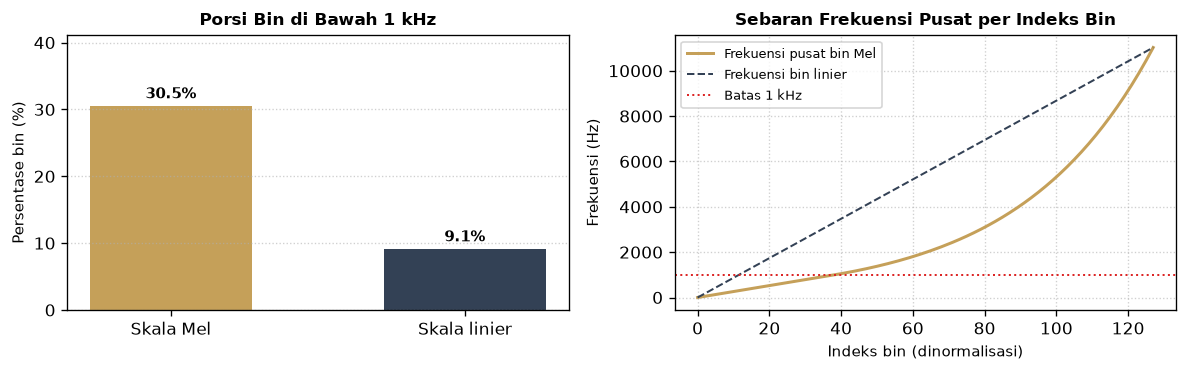

In [23]:
f_mel = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=SR / 2)
f_lin = np.fft.rfftfreq(N_FFT_BANDING, 1 / SR)

n_mel_vokal = int(np.sum(f_mel < BATAS_VOKAL_HZ))
n_lin_vokal = int(np.sum(f_lin < BATAS_VOKAL_HZ))
p_mel = 100 * n_mel_vokal / len(f_mel)
p_lin = 100 * n_lin_vokal / len(f_lin)

print(f"Skala Mel    : {n_mel_vokal:>4} dari {len(f_mel):>4} bin di bawah 1 kHz  = {p_mel:5.1f}%")
print(f"Skala linier : {n_lin_vokal:>4} dari {len(f_lin):>4} bin di bawah 1 kHz  = {p_lin:5.1f}%")
print(f"\nFaktor pembesaran daerah vokal: {p_mel / p_lin:.1f}×")
print("\n✅ Klaim pada materi kuliah TERBUKTI secara kuantitatif.")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

axes[0].bar(['Skala Mel', 'Skala linier'], [p_mel, p_lin],
            color=[C_GOLD, C_NEUTRAL], width=0.55)
for i, v in enumerate((p_mel, p_lin)):
    axes[0].text(i, v + 1.2, f"{v:.1f}%", ha='center', fontsize=9, fontweight='bold')
axes[0].set_title("Porsi Bin di Bawah 1 kHz", fontsize=10, fontweight='bold')
axes[0].set_ylabel("Persentase bin (%)", fontsize=9)
axes[0].set_ylim(0, max(p_mel, p_lin) * 1.35)
axes[0].grid(True, axis='y', linestyle=':', alpha=0.6)

axes[1].plot(np.arange(len(f_mel)), f_mel, color=C_GOLD, lw=1.8, label='Frekuensi pusat bin Mel')
axes[1].plot(np.linspace(0, len(f_mel) - 1, len(f_lin)), f_lin, color=C_NEUTRAL,
             lw=1.2, linestyle='--', label='Frekuensi bin linier')
axes[1].axhline(BATAS_VOKAL_HZ, color=C_ALERT, lw=1.2, linestyle=':', label='Batas 1 kHz')
axes[1].set_title("Sebaran Frekuensi Pusat per Indeks Bin", fontsize=10, fontweight='bold')
axes[1].set_xlabel("Indeks bin (dinormalisasi)", fontsize=9)
axes[1].set_ylabel("Frekuensi (Hz)", fontsize=9)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 11. Rangkuman & Kesimpulan

1. **Tidak ada satu tampilan yang sempurna.** Waktu, frekuensi, dan amplitudo tidak dapat
   ditampilkan tajam secara bersamaan. Setiap representasi visual adalah hasil pertukaran yang
   disengaja, dan memilih tampilan berarti memilih informasi apa yang bersedia kita korbankan.
2. **Waveform buta terhadap frekuensi.** Dentuman bass $60\text{ Hz}$ dan vokal $3\text{ kHz}$
   menghasilkan tinggi waveform yang identik. Dengung $50\text{ Hz}$ yang jelas terdengar telinga
   praktis tidak meninggalkan jejak kasatmata pada tampilan ini.
3. **Angka dBFS hanya bermakna bila terkalibrasi.** Normalisasi terhadap $\sum w$ disertai
   pengali $2$ untuk spektrum satu sisi membuat nada beramplitudo $1{,}0$ berpuncak tepat di
   $0\text{ dBFS}$. Tanpa koreksi tersebut, sumbu Y hanya berupa angka relatif tanpa arti fisis.
4. **Spektrum FFT adalah alat forensik.** Dengan membandingkan spektrum sebelum dan sesudah,
   frekuensi dengung beserta harmoniknya dapat ditemukan secara otomatis — sebuah pekerjaan yang
   mustahil dilakukan pada domain waktu.
5. **Spektrogram menggabungkan waktu dan frekuensi, dengan harga yang harus dibayar.** Parameter
   `n_fft` mengatur pertukaran tersebut: $\Delta f = f_s / n_{\text{fft}}$. Pada $f_s = 22.050\text{ Hz}$,
   nilai `n_fft = 256` menghasilkan $\Delta f = 86\text{ Hz}$ sehingga garis dengung $50\text{ Hz}$
   lenyap, sedangkan `n_fft = 4096` menampilkannya dengan tegas namun mengaburkan transien.
6. **Skala Mel meniru persepsi telinga, dan hal ini terukur.** Dari $128$ bin Mel, sekitar $30\%$
   berpusat di bawah $1\text{ kHz}$, dibandingkan hanya $9\%$ pada bin FFT linier — memperbesar
   daerah vokal sekitar $3{,}3\times$. Di sinilah letak keunggulannya sebagai masukan model AI audio.
7. **Perhatikan konvensi pustaka.** `melspectrogram` mengembalikan *power* sehingga memerlukan
   `power_to_db`, sedangkan magnitudo STFT memerlukan `amplitude_to_db`. Rumus Mel pada slide
   adalah varian **HTK**, sementara bawaan librosa adalah varian **Slaney** — sebutkan `htk=True`
   secara eksplisit apabila angkanya hendak dicocokkan.
8. **Pembacaan visual mendahului pemrosesan.** Seluruh keputusan *Equalizer* pada Modul 03 —
   di mana harus memotong, berapa lebar, seberapa dalam — berawal dari kemampuan membaca
   gambar-gambar yang telah kita pelajari di sini.

---
© IF25-40305 Sistem Teknologi Multimedia — Institut Teknologi Sumatera (ITERA).